<a href="https://colab.research.google.com/github/Wesnei/Imputation-and-Sampling/blob/main/Imputation_and_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://github.com/sauloafoliveira/ppgcc-deep-learning/blob/main/ppgc_logo.png?raw=true" width="450">
  <br>
  <font size="4"><b>INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO CEARÁ</b></font><br>
  <font size="3"><b>PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO - PPGCC</b></font><br>
  <font size="3">Mestrado Acadêmico em Ciência da Computação</font>
</div>

---
**Disciplina:** DEEP GENERATIVE MODELS – 2026.2

**Docentes:** Prof. Dr. Saulo Oliveira  
**Discente:** Wesnei de Paiva Batista  
**Atividade:** Imputação e Amostragem

---



# 1. INTRODUÇÃO

Neste relatório prático da disciplina de Modelos Generativos Profundos, o foco é resolver dois dos problemas mais críticos na preparação de dados: a falta de volume e a presença de valores nulos. Qualquer modelo de aprendizado de máquina sofre com dados escassos ou incompletos, e simplesmente descartar registros corrompidos raramente é a melhor saída estatística.

A atividade é dividida em duas frentes. Na Parte A, utilizamos o dataset da Coluna Vertebral para aplicar técnicas de geração de dados sintéticos. O objetivo é testar como abordagens probabilísticas lidam com a expansão da base. Treinamos um Naïve Bayes com apenas 50% dos dados originais para guiar a geração de novas amostras e, em um segundo momento, aplicamos o método da rejeição. Nesse último cenário, usamos uma normal multivariada como distribuição de proposta e uma Regressão Logística treinada com toda a base original para calcular a probabilidade de aceitação de cada nova amostra.

Na Parte B, o problema passa a ser a reconstrução de dados ausentes. Pegamos o clássico dataset Íris e apagamos 10% dos valores aleatoriamente. Com essa matriz corrompida, rodamos três métodos de imputação: o simples Valor Esperado, K-NN e Regressão Linear. A ideia final é avaliar o RMSE de cada abordagem e discutir qual técnica consegue preservar melhor a estrutura original e as relações entre as variáveis.

# 2. Parte A: Geração de Amostras (Coluna Vertebral)

## Discussão - Geração de Amostras:

Avaliando as projeções em 2D geradas pelo PCA, fica evidente como a premissa matemática de cada modelo dita a forma dos dados sintéticos. Os Dados Reais possuem uma estrutura orgânica bem definida, formando clusters densos com certa curvatura.   

Ao gerar amostras com o Naïve Bayes, a suposição de independência condicional entre os atributos forçou a distribuição a assumir um formato de elipses espalhadas. Ele até conseguiu separar as classes grosseiramente, mas perdeu a correlação geométrica original.   

Já o Método da Rejeição usando Regressão Logística gerou um resultado surpreendente: uma grande nuvem esférica e difusa. Isso ocorreu porque utilizamos uma Normal Multivariada global como proposta. A função sigmoide da Regressão Logística apenas cortou esse espaço, aceitando os pontos que caíam no lado correto da fronteira de decisão, mas ignorando completamente a densidade estrutural (o manifold) em que os dados originais realmente habitam.

## Instalação e Carregamento do Dataset do Prof. Ajalmar

In [4]:
!pip install ucimlrepo

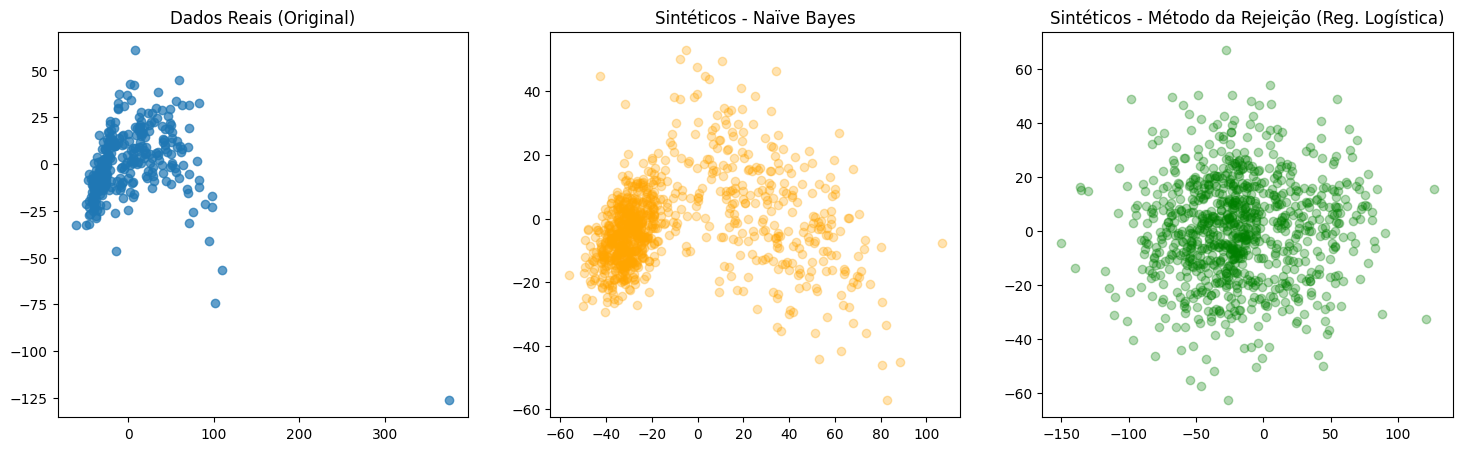

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

vertebral_column = fetch_ucirepo(id=212)
X_orig = vertebral_column.data.features.values
y_orig = vertebral_column.data.targets.values.ravel()
classes = np.unique(y_orig)

X_train, X_test, y_train, y_test = train_test_split(X_orig, y_orig, test_size=0.5, random_state=42)
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

synthetic_data_nb = []
synthetic_labels_nb = []

for c in classes:
    subset = X_train[y_train == c]
    mean = np.mean(subset, axis=0)
    cov = np.diag(np.var(subset, axis=0))

    gen_samples = np.random.multivariate_normal(mean, cov, 300)
    synthetic_data_nb.append(gen_samples)
    synthetic_labels_nb.extend([c] * 300)

X_syn_nb = np.vstack(synthetic_data_nb)
y_syn_nb = np.array(synthetic_labels_nb)

lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_orig, y_orig)

mean_global = np.mean(X_orig, axis=0)
cov_global = np.cov(X_orig, rowvar=False)

def rejection_sampling(n_target, mean, cov, model, class_label):
    accepted = []
    class_idx = list(model.classes_).index(class_label)
    while len(accepted) < n_target:
        x_prop = np.random.multivariate_normal(mean, cov)
        u = np.random.uniform(0, 1)
        proba = model.predict_proba([x_prop])[0][class_idx]
        if u < proba:
            accepted.append(x_prop)
    return np.array(accepted)

synthetic_data_rej = []
synthetic_labels_rej = []

for c in classes:
    samples_c = rejection_sampling(300, mean_global, cov_global, lr_clf, c)
    synthetic_data_rej.append(samples_c)
    synthetic_labels_rej.extend([c] * 300)

X_syn_rej = np.vstack(synthetic_data_rej)
y_syn_rej = np.array(synthetic_labels_rej)

pca = PCA(n_components=2)
X_orig_pca = pca.fit_transform(X_orig)
X_syn_nb_pca = pca.transform(X_syn_nb)
X_syn_rej_pca = pca.transform(X_syn_rej)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_orig_pca[:, 0], X_orig_pca[:, 1], alpha=0.7)
axes[0].set_title('Dados Reais (Original)')

axes[1].scatter(X_syn_nb_pca[:, 0], X_syn_nb_pca[:, 1], alpha=0.3, color='orange')
axes[1].set_title('Sintéticos - Naïve Bayes')

axes[2].scatter(X_syn_rej_pca[:, 0], X_syn_rej_pca[:, 1], alpha=0.3, color='green')
axes[2].set_title('Sintéticos - Método da Rejeição (Reg. Logística)')

plt.show()

# 3. Parte B: Preenchendo Lacunas (Conjunto Íris)

## Discussão - Imputação de Dados:
A métrica de RMSE confirmou drasticamente a diferença entre tratar dados ausentes com abordagens ingênuas versus abordagens correlacionais. O Valor Esperado (Média) obteve o pior desempenho isolado (RMSE de 1.035). Preencher lacunas com a média destrói a variância e ignora a dinâmica natural da flor.

O K-NN obteve um desempenho intermediário (RMSE de 0.566). Embora seja ótimo para agrupar vizinhos, ele foi superado pela Regressão Linear, que se consagrou como a melhor técnica para esse cenário específico (RMSE de 0.446). O sucesso da Regressão Linear se justifica pela forte correlação linear existente entre as variáveis do dataset Íris (como o comprimento e a largura da pétala). Usar os atributos sobreviventes para traçar uma reta preditiva do valor ausente preservou a integridade estatística da base muito melhor do que a média ou a proximidade espacial geométrica (K-NN).


In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

iris = load_iris()
X_orig = iris.data

np.random.seed(42)
n_missing = 180

flattened_indices = np.random.choice(X_orig.size, n_missing, replace=False)
X_nan_flat = X_orig.flatten().copy()
X_nan_flat[flattened_indices] = np.nan
X_nan = X_nan_flat.reshape(X_orig.shape)

mask = np.isnan(X_nan)

imp_mean = SimpleImputer(strategy='mean')
X_mean = imp_mean.fit_transform(X_nan)

imp_knn = KNNImputer(n_neighbors=5)
X_knn = imp_knn.fit_transform(X_nan)

imp_lr = IterativeImputer(estimator=LinearRegression(), random_state=42, max_iter=100)
X_lr = imp_lr.fit_transform(X_nan)

def calc_rmse(imputed_data):
    return np.sqrt(mean_squared_error(X_orig[mask], imputed_data[mask]))

rmse_mean = calc_rmse(X_mean)
rmse_knn = calc_rmse(X_knn)
rmse_lr = calc_rmse(X_lr)

df_resultados = pd.DataFrame({
    'Método de Imputação': ['Valor Esperado (Média)', 'Regressão Linear', 'K-NN'],
    'RMSE': [rmse_mean, rmse_lr, rmse_knn]
}).sort_values(by='RMSE')

print("=== COMPARAÇÃO DE RMSE ===")
print(df_resultados.to_string(index=False))

=== COMPARAÇÃO DE RMSE ===
   Método de Imputação     RMSE
      Regressão Linear 0.440386
                  K-NN 0.566319
Valor Esperado (Média) 1.035641


# 4. Conclusão

Os experimentos evidenciaram que gerar amostras ou imputar valores exige respeito à distribuição original. No preenchimento de lacunas (Íris), assumir relações lineares (Regressão) ou de vizinhança (K-NN) reduziu o erro pela metade em comparação à imputação ingênua pela média, com a Regressão Linear apresentando a maior fidelidade na reconstrução (RMSE 0.446).

Na geração de dados (Coluna Vertebral), observamos as severas limitações de métodos probabilísticos clássicos. O Naïve Bayes gerou nuvens distorcidas pela premissa de independência, enquanto o método da rejeição criou uma dispersão irreal por basear-se em uma distribuição de proposta global.

Como desdobramento direto e alinhado aos objetivos da disciplina de Modelos Generativos Profundos, propõe-se como trabalho futuro a expansão da Parte A substituindo essas abordagens clássicas por Autoencoders Variacionais (VAEs). A amostragem direta do espaço latente de um VAE tem o potencial de capturar a covariância complexa e não linear que as características ortopédicas reais possuem, algo que tanto o Naïve Bayes quanto a Regressão Logística falharam em modelar visualmente.